# Motor Imagery Classification — PhysioNet EEG Dataset
1 subject, 3 runs. Light enough for 8GB RAM.
Pipeline: load → filter → epoch → CSP → classify.

In [13]:
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

## 1. Download data (subset only — ~10MB)

In [14]:
raw_fnames = mne.datasets.eegbci.load_data(subjects=1, runs=[6, 10, 14])
raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
raw = mne.concatenate_raws(raws)
raw.rename_channels(lambda x: x.strip('.'))
print(raw.info)

Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_

## 2. Filter (mu/beta band, 7-30 Hz)

In [15]:
raw.filter(7., 30., fir_design='firwin', skip_by_annotation='edge')

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

## 3. Epoch by event

In [ ]:
# events, event_id = mne.events_from_annotations(raw)
# print(event_id)

# epochs = mne.Epochs(raw, events, event_id, tmin=-1., tmax=4.,
#                      baseline=None, preload=True)
# print(epochs)
subjects = [1, 2, 3, 4, 5]
all_epochs = []

for subj in subjects:
    raw_fnames = mne.datasets.eegbci.load_data(subjects =subj, runs=[6, 10, 14])
    raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
    raw = mne.concatenate_raws(raws)
    raw.rename_channels(lambda x: x.strip('.'))
    raw.filter(7., 30., fir_design='firwin', skip_by_annotation='edge')

    events, event_id = mne.events_from_annotations(raw)
    epochs = mne.Epochs(raw, events, event_id, tmin=-1., tmax=4.,
                         baseline=None, preload=True)
    all_epochs.append(epochs)

epochs = mne.concatenate_epochs(all_epochs)
X = epochs.get_data(copy=False)
y = epochs.events[:, -1]
print(X.shape, y.shape)

Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopba

Download complete in 04m20s (7.3 MB)
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.

Download complete in 04m34s (7.4 MB)
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S003\S003R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S003\S003R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S003\S003R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.

Download complete in 04m10s (7.3 MB)
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S004\S004R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S004\S004R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S004\S004R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.

Download complete in 04m16s (7.3 MB)
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S005\S005R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S005\S005R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from C:\Users\saran\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S005\S005R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.

C:\Users\saran\AppData\Local\Temp\ipykernel_9888\2120482413.py:22: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(all_epochs)


## 4. CSP feature extraction

In [17]:
X = epochs.get_data(copy=False)
y = epochs.events[:, -1]

csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
X_csp = csp.fit_transform(X, y)
print(X_csp.shape)

Computing rank from data with rank=None
    Using tolerance 0.00084 (2.2e-16 eps * 64 dim * 5.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
(435, 4)


## 5. Classify (SVM, 5-fold CV)

In [18]:
clf = SVC(kernel='linear')
scores = cross_val_score(clf, X_csp, y, cv=5)
print(f"Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

Accuracy: 0.48 ± 0.00


## 6. Confusion matrix (sanity check)

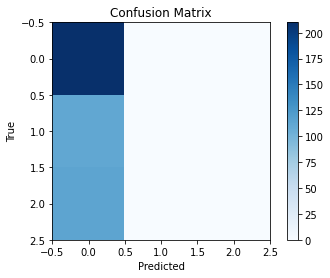

In [19]:
y_pred = cross_val_predict(clf, X_csp, y, cv=5)
cm = confusion_matrix(y, y_pred)
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## CSP + LDA vs CSP + SVM comparison

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

pipe_lda = Pipeline([('CSP', csp), ('LDA', LinearDiscriminantAnalysis())])
pipe_svm = Pipeline([('CSP', csp), ('SVM', SVC(kernel='linear'))])

scores_lda = cross_val_score(pipe_lda, X, y, cv=5)
scores_svm = cross_val_score(pipe_svm, X, y, cv=5)

print(f"LDA: {scores_lda.mean():.2f} ± {scores_lda.std():.2f}")
print(f"SVM: {scores_svm.mean():.2f} ± {scores_svm.std():.2f}")

Computing rank from data with rank=None
    Using tolerance 0.00068 (2.2e-16 eps * 64 dim * 4.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0008 (2.2e-16 eps * 64 dim * 5.6e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00064 (2.2e-16 eps * 64 dim * 4.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 d

In [21]:
### Spatial plot

csp.fit(X, y)
csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)

Computing rank from data with rank=None
    Using tolerance 0.00084 (2.2e-16 eps * 64 dim * 5.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


AttributeError: 'NoneType' object has no attribute 'ndim'

In [ ]:
for n in [2, 4, 6, 8]:
    csp_n = CSP(n_components=n, reg=None, log=True, norm_trace=False)
    pipe = Pipeline([('CSP', csp_n), ('LDA', LinearDiscriminantAnalysis())])
    scores = cross_val_score(pipe, X, y, cv=5)
    print(f"n_components={n}: {scores.mean():.2f} ± {scores.std():.2f}")